In [115]:
# ==========================================================
# Project: Netflix India Content Deep Dive
# Step 1: Data Understanding
# Author: Ankit Jangid
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [116]:
# Load Dataset
df = pd.read_csv("../Dataset/netflix_titles.csv")


In [117]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [118]:
# Check the number of rows and columns
df.shape

(8807, 12)

In [119]:
# Display all column names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [120]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [121]:
# Check missing values in each column
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [122]:
# Check duplicate rows
df.duplicated().sum()

0

In [123]:
# Display missing values only
df[['director', 'country', 'date_added', 'rating']].isnull().sum()


director      2634
country        831
date_added      10
rating           4
dtype: int64

In [124]:
# Show rows where country is missing
df[df['country'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8718,s8719,Movie,Westside vs. the World,Michael Fahey,"Ron Perlman, Louie Simmons",NaN,"August 9, 2019",2019,TV-MA,96 min,"Documentaries, Sports Movies",A look into the journey of influential strengt...
8759,s8760,Movie,World's Weirdest Homes,Storm Theunissen,Charlie Luxton,NaN,"February 1, 2019",2015,TV-PG,49 min,Movies,From a bubble-shaped palace to an island built...
8783,s8784,TV Show,Yoko,NaN,"Eileen Stevens, Alyson Leigh Rosenfeld, Sarah ...",NaN,"June 23, 2018",2016,TV-Y,1 Season,Kids' TV,"Friends Mai, Oto and Vik's games at the park b..."
8785,s8786,TV Show,YOM,NaN,"Sairaj, Devyani Dagaonkar, Ketan Singh, Mayur ...",NaN,"June 7, 2018",2016,TV-Y7,1 Season,Kids' TV,"With the mind of a human being, and the body o..."


In [125]:
# Calculate missing percentage for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [126]:
# Display unique countries
df['country'].unique()

array(['United States', 'South Africa', nan, 'India',
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'Mexico', 'Turkey',
       'Australia', 'United States, India, France', 'Finland',
       'China, Canada, United States',
       'South Africa, United States, Japan', 'Nigeria', 'Japan',
       'Spain, United States', 'France', 'Belgium',
       'United Kingdom, United States', 'United States, United Kingdom',
       'France, United States', 'South Korea', 'Spain',
       'United States, Singapore', 'United Kingdom, Australia, France',
       'United Kingdom, Australia, France, United States',
       'United States, Canada', 'Germany, United States',
       'South Africa, United States', 'United States, Mexico',
       'United States, Italy, France, Japan',
       'United States, Italy, Romania, United Kingdom',
       'Australia, United States', 'Argentina, Venezuela',
       'United States, United Kin

In [127]:
df['country'].nunique()

748

In [128]:
df['country'].str.contains('India', na=False)

0       False
1       False
2       False
3       False
4        True
        ...  
8802    False
8803    False
8804    False
8805    False
8806     True
Name: country, Length: 8807, dtype: bool

In [129]:
# Fill missing values in the country column
df['country'] = df['country'].fillna('Unknown')

In [130]:
# Verify missing values in country
df['country'].isnull().sum()

0

In [131]:
# Check the data type of date_added
df['date_added'].dtype

dtype('O')

In [132]:
df['date_added'].dtype

dtype('O')

In [133]:
# Display first 5 dates
df['date_added'].head()

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: object

In [136]:
# Convert date_added to datetime
df["date_added"] = pd.to_datetime(
    df["date_added"].astype(str).str.strip(),
    errors="coerce"
)

# Create year_added
df["year_added"] = df["date_added"].dt.year.astype("Int64")

In [137]:
# Display date_added and year_added
df[['date_added', 'year_added']].head()

,date_added,year_added
0,2021-09-25,2021
1,2021-09-24,2021
2,2021-09-24,2021
3,2021-09-24,2021
4,2021-09-24,2021


In [140]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

In [141]:
# Create a new dataframe containing only Indian Netflix content
india_df = df[df['country'].str.contains('India', na=False)].copy()

In [142]:
# Check the size of the Indian dataset
india_df.shape

(1046, 13)

In [143]:
# Total Indian Titles
print("Total Indian Titles:", len(india_df))

Total Indian Titles: 1046


In [144]:
# Count Movies and TV Shows
india_df['type'].value_counts()

type
Movie      962
TV Show     84
Name: count, dtype: int64

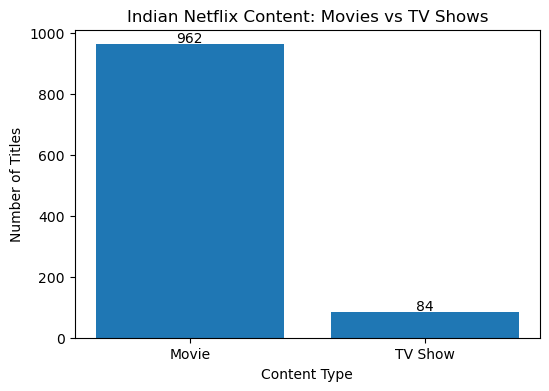

In [145]:
import matplotlib.pyplot as plt

# Count Movies and TV Shows
type_counts = india_df['type'].value_counts()

# Create Bar Chart
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values)

# Title and Labels
plt.title('Indian Netflix Content: Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

# Display values on bars
for i, value in enumerate(type_counts.values):
    plt.text(i, value + 5, str(value), ha='center')

plt.show()

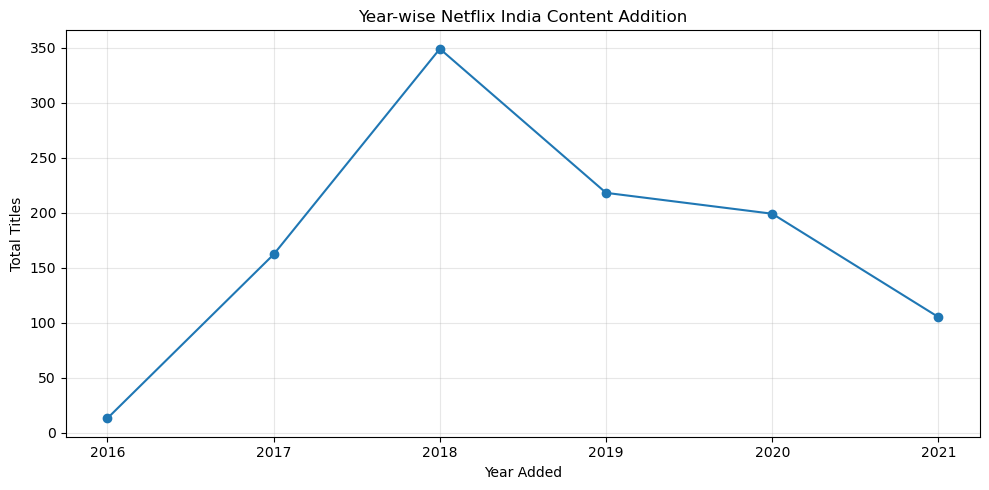

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_content["year_added"],
    yearly_content["Total_Content"],
    marker="o"
)

plt.title("Year-wise Netflix India Content Addition")
plt.xlabel("Year Added")
plt.ylabel("Total Titles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [169]:
# Make sure year_added exists
india_df["date_added"] = pd.to_datetime(
    india_df["date_added"].astype("string").str.strip(),
    errors="coerce"
)

india_df["year_added"] = india_df["date_added"].dt.year.astype("Int64")

# Year-wise Indian content addition
yearly_content = (
    india_df
    .dropna(subset=["year_added"])
    .groupby("year_added")
    .size()
    .reset_index(name="Total_Content")
    .sort_values("year_added")
)

yearly_content

,year_added,Total_Content
0,2016,13
1,2017,162
2,2018,349
3,2019,218
4,2020,199
5,2021,105


In [172]:
# Top 10 Indian Directors
top_directors = india_df['director'].value_counts().head(10)

top_directors

director
David Dhawan          9
Ram Gopal Varma       7
Imtiaz Ali            6
Anees Bazmee          6
Rajkumar Santoshi     6
Ashutosh Gowariker    6
Sooraj R. Barjatya    6
Prakash Jha           5
Vishal Bhardwaj       5
Priyadarshan          5
Name: count, dtype: int64

In [173]:
# Top 10 Genres in Indian Netflix Content
top_genres = india_df['listed_in'].value_counts().head(10)

top_genres

listed_in
Comedies, Dramas, International Movies              124
Dramas, International Movies                        123
Dramas, Independent Movies, International Movies    121
Dramas, International Movies, Romantic Movies        64
Action & Adventure, Dramas, International Movies     55
Dramas, International Movies, Thrillers              44
Comedies, International Movies, Romantic Movies      42
Dramas, International Movies, Music & Musicals       39
Comedies, International Movies, Music & Musicals     35
Comedies, Dramas, Independent Movies                 28
Name: count, dtype: int64

In [174]:
india_df['listed_in'].value_counts()

listed_in
Comedies, Dramas, International Movies                   124
Dramas, International Movies                             123
Dramas, Independent Movies, International Movies         121
Dramas, International Movies, Romantic Movies             64
Action & Adventure, Dramas, International Movies          55
                                                        ... 
International TV Shows, TV Dramas, TV Horror               1
Comedies, International Movies, Sports Movies              1
Children & Family Movies, Dramas, Independent Movies       1
International TV Shows, Reality TV, Romantic TV Shows      1
Comedies, Dramas                                           1
Name: count, Length: 99, dtype: int64

In [175]:
# Split multiple genres into individual genres
genres = india_df['listed_in'].str.split(', ').explode()

In [176]:
# Top 10 Individual Genres
top_genres = genres.value_counts().head(10)

top_genres

listed_in
International Movies      864
Dramas                    662
Comedies                  323
Independent Movies        167
Action & Adventure        137
Romantic Movies           120
Music & Musicals           96
Thrillers                  92
International TV Shows     66
Horror Movies              35
Name: count, dtype: int64

In [177]:
india_df['rating'].value_counts()

rating
TV-14       572
TV-MA       266
TV-PG       144
TV-Y7        17
PG-13        11
TV-G         10
PG            7
NR            7
TV-Y          6
R             5
TV-Y7-FV      1
Name: count, dtype: int64

In [178]:
# Rating distribution by Content Type
rating_by_type = pd.crosstab(india_df['rating'], india_df['type'])

rating_by_type

type,Movie,TV Show
rating,,
NR,7,0
PG,7,0
PG-13,11,0
R,5,0
TV-14,547,25
TV-G,7,3
TV-MA,232,34
TV-PG,133,11
TV-Y,0,6


In [179]:
# Export cleaned dataset
india_df.to_csv("netflix_india_cleaned.csv", index=False)

In [180]:
# Export genre dataset
genres.to_frame(name='Genre').to_csv("netflix_india_genres.csv", index=False)

In [181]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nCSV Files:")
for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

Current Folder:
C:\Users\iaman\Documents\Netflix_India_Content_Deep_Dive\Python

CSV Files:
netflix_india_cleaned.csv
netflix_india_genres.csv


In [182]:
# Create a proper Genre table for Power BI

genres_df = india_df[['show_id', 'listed_in']].copy()

genres_df['Genre'] = genres_df['listed_in'].str.split(', ')

genres_df = genres_df.explode('Genre')

genres_df = genres_df[['show_id', 'Genre']]

genres_df.head()

,show_id,Genre
4,s5,International TV Shows
4,s5,Romantic TV Shows
4,s5,TV Comedies
24,s25,Comedies
24,s25,International Movies


In [183]:
genres_df.to_csv("netflix_india_genres.csv", index=False)

In [184]:
genres_df.head()

,show_id,Genre
4,s5,International TV Shows
4,s5,Romantic TV Shows
4,s5,TV Comedies
24,s25,Comedies
24,s25,International Movies


In [185]:
# Total Indian Titles
print("Total Indian Titles:", len(india_df))

Total Indian Titles: 1046


In [186]:
# Movies vs TV Shows
india_df['type'].value_counts()

type
Movie      962
TV Show     84
Name: count, dtype: int64

In [187]:
# Movies vs TV Shows Percentage
round(india_df['type'].value_counts(normalize=True) * 100, 2)

type
Movie      91.97
TV Show     8.03
Name: proportion, dtype: float64

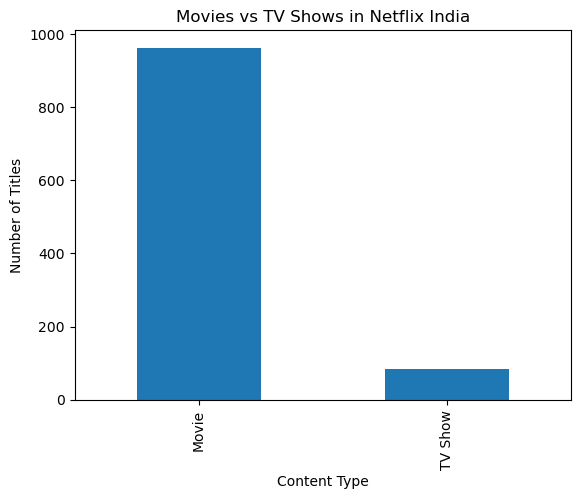

In [188]:
# Movies vs TV Shows Bar Chart

india_df['type'].value_counts().plot(kind='bar')

plt.title("Movies vs TV Shows in Netflix India")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [189]:
# Convert date_added to datetime
india_df["date_added"] = pd.to_datetime(
    india_df["date_added"].astype("string").str.strip(),
    errors="coerce"
)

# Create year_added column
india_df["year_added"] = india_df["date_added"].dt.year.astype("Int64")

# Check required columns
print(india_df[["date_added", "year_added", "type"]].head())

   date_added  year_added     type
4  2021-09-24        2021  TV Show
24 2021-09-21        2021    Movie
29 2021-09-19        2021    Movie
39 2021-09-16        2021  TV Show
50 2021-09-15        2021  TV Show


In [190]:
# Year-wise Indian content addition trend
yearly_content = (
    india_df
    .dropna(subset=["year_added"])
    .groupby(["year_added", "type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

yearly_content

type,Movie,TV Show
year_added,,
2016,13,0
2017,148,14
2018,332,17
2019,200,18
2020,181,18
2021,88,17


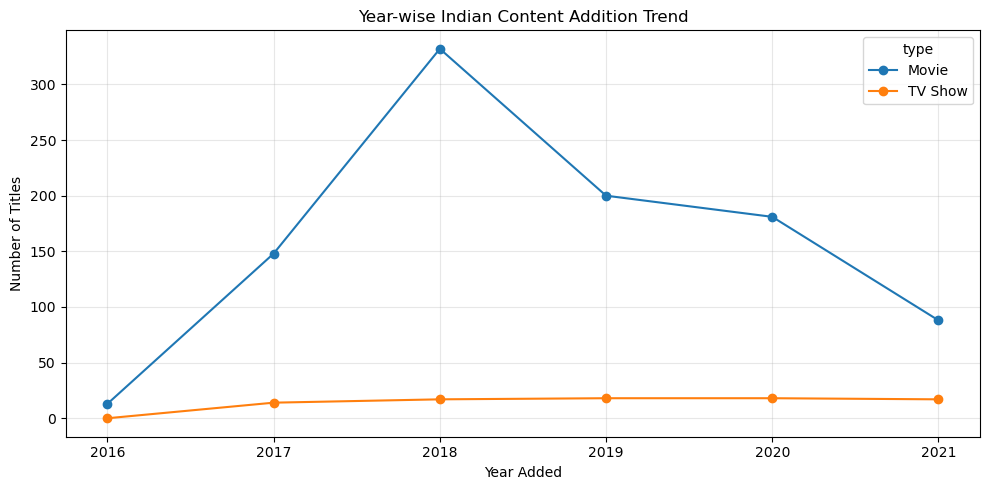

In [191]:
import matplotlib.pyplot as plt

yearly_content.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Year-wise Indian Content Addition Trend")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [192]:
print(india_df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added']


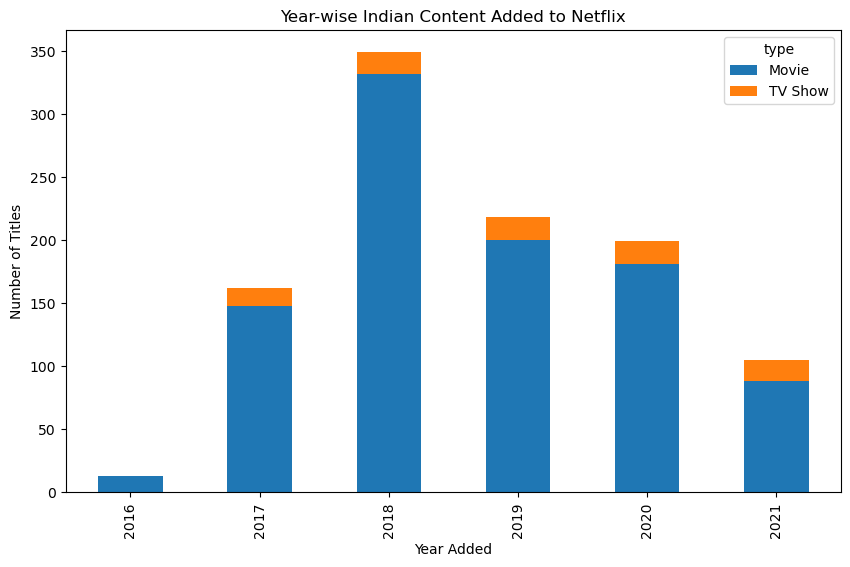

In [193]:
# Year-wise Indian Content Addition Trend

yearly_content.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Year-wise Indian Content Added to Netflix")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.show()

In [194]:
# Top 10 Indian Directors

top_directors = (
    india_df['director']
    .value_counts()
    .head(10)
)

top_directors

director
David Dhawan          9
Ram Gopal Varma       7
Imtiaz Ali            6
Anees Bazmee          6
Rajkumar Santoshi     6
Ashutosh Gowariker    6
Sooraj R. Barjatya    6
Prakash Jha           5
Vishal Bhardwaj       5
Priyadarshan          5
Name: count, dtype: int64

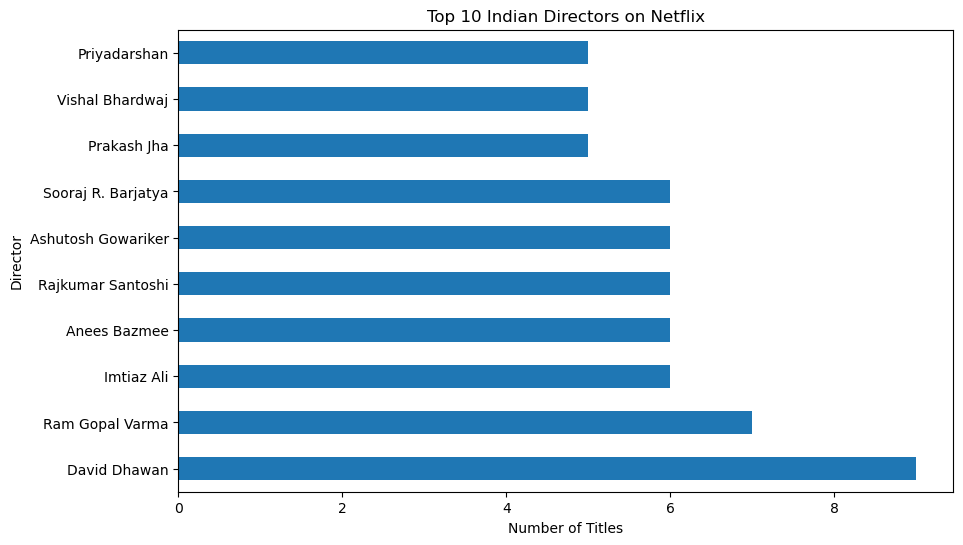

In [195]:
# Top 10 Indian Directors

top_directors.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Top 10 Indian Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

In [196]:
# Split genres into separate rows
india_genres = (
    india_df['listed_in']
    .str.split(', ')
    .explode()
)

# Top 10 Genres
top_genres = india_genres.value_counts().head(10)

top_genres

listed_in
International Movies      864
Dramas                    662
Comedies                  323
Independent Movies        167
Action & Adventure        137
Romantic Movies           120
Music & Musicals           96
Thrillers                  92
International TV Shows     66
Horror Movies              35
Name: count, dtype: int64

In [197]:
# Create Global Genre List
global_genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
)

# Top 10 Global Genres
top_global_genres = global_genres.value_counts().head(10)

top_global_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [198]:
# Rating Breakdown
india_df['rating'].value_counts()

rating
TV-14       572
TV-MA       266
TV-PG       144
TV-Y7        17
PG-13        11
TV-G         10
PG            7
NR            7
TV-Y          6
R             5
TV-Y7-FV      1
Name: count, dtype: int64

In [199]:
top20 = df[["title","description"]].head(20)

top20

,title,description
0,Dick Johnson Is Dead,"As her father nears the end of his life, filmm..."
1,Blood & Water,"After crossing paths at a party, a Cape Town t..."
2,Ganglands,To protect his family from a powerful drug lor...
3,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo..."
4,Kota Factory,In a city of coaching centers known to train I...
5,Midnight Mass,The arrival of a charismatic young priest brin...
6,My Little Pony: A New Generation,Equestria's divided. But a bright-eyed hero be...
7,Sankofa,"On a photo shoot in Ghana, an American model s..."
8,The Great British Baking Show,A talented batch of amateur bakers face off in...
9,The Starling,A woman adjusting to life after a loss contend...


In [200]:
top20 = df[
    df["country"].str.contains("India", na=False)
][["title", "description"]].head(20)

top20

,title,description
4,Kota Factory,In a city of coaching centers known to train I...
24,Jeans,When the father of the man she loves insists t...
29,Paranoia,"Blackmailed by his company's CEO, a low-level ..."
39,Chhota Bheem,"A brave, energetic little boy with superhuman ..."
50,Dharmakshetra,"After the ancient Great War, the god Chitragup..."
66,Raja Rasoi Aur Anya Kahaniyan,Explore the history and flavors of regional In...
69,Stories by Rabindranath Tagore,The writings of Nobel Prize winner Rabindranat...
105,Angamaly Diaries,After growing up amidst the gang wars of his h...
114,Anjaam,A wealthy industrialist’s dangerous obsession ...
116,Dhanak,A movie-loving 10-year-old and her blind littl...


In [201]:
def classify_theme(description):
    text = str(description).lower()

    if any(word in text for word in [
        "crime", "murder", "gang", "police", "investigation",
        "blackmail", "framed", "underworld", "obsession"
    ]):
        return "Crime & Thriller"

    elif any(word in text for word in [
        "love", "couple", "romance", "marriage", "relationship"
    ]):
        return "Romance"

    elif any(word in text for word in [
        "child", "boy", "girl", "family", "father", "mother"
    ]):
        return "Family & Children"

    elif any(word in text for word in [
        "history", "ancient", "war", "god", "writings",
        "culture", "regional", "tradition"
    ]):
        return "Historical & Cultural"

    elif any(word in text for word in [
        "student", "coaching", "education", "school", "college"
    ]):
        return "Education & Youth"

    elif any(word in text for word in [
        "comedy", "friends", "funny", "humor"
    ]):
        return "Comedy"

    elif any(word in text for word in [
        "social", "poverty", "rights", "justice", "society"
    ]):
        return "Social Issues"

    else:
        return "Other"

In [202]:
top20["Theme"] = top20["description"].apply(classify_theme)

top20

,title,description,Theme
4,Kota Factory,In a city of coaching centers known to train I...,Education & Youth
24,Jeans,When the father of the man she loves insists t...,Romance
29,Paranoia,"Blackmailed by his company's CEO, a low-level ...",Crime & Thriller
39,Chhota Bheem,"A brave, energetic little boy with superhuman ...",Family & Children
50,Dharmakshetra,"After the ancient Great War, the god Chitragup...",Historical & Cultural
66,Raja Rasoi Aur Anya Kahaniyan,Explore the history and flavors of regional In...,Historical & Cultural
69,Stories by Rabindranath Tagore,The writings of Nobel Prize winner Rabindranat...,Historical & Cultural
105,Angamaly Diaries,After growing up amidst the gang wars of his h...,Crime & Thriller
114,Anjaam,A wealthy industrialist’s dangerous obsession ...,Crime & Thriller
116,Dhanak,A movie-loving 10-year-old and her blind littl...,Family & Children


In [203]:
theme_summary = top20["Theme"].value_counts().reset_index()
theme_summary.columns = ["Theme", "Total_Titles"]

theme_summary

,Theme,Total_Titles
0,Crime & Thriller,6
1,Family & Children,4
2,Romance,3
3,Historical & Cultural,3
4,Education & Youth,2
5,Other,1
6,Comedy,1


In [204]:
top20.to_csv("../Dataset/top20_theme_categorization.csv", index=False)

print("Theme categorization completed successfully!")

Theme categorization completed successfully!
